<a href="https://colab.research.google.com/github/aparna-2001/nifty50-stock-price-forecasting/blob/main/crude_oil_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

In [15]:
crude_raw = yf.download('CL=F', start='1999-01-01', end='2026-03-01')
crude_raw.columns = crude_raw.columns.get_level_values(0)  # flatten columns

crude_df = crude_raw.resample('MS').agg(
    Month_Open  = ('Open',  'first'),
    Month_Close = ('Close', 'last'),
    Month_High  = ('High',  'max'),
    Month_Low   = ('Low',   'min'),
    Avg_Volume  = ('Volume','mean')
).reset_index().rename(columns={'Date': 'Month'})

crude_df.dropna(inplace=True)
print(crude_df.shape)
print(crude_df.head())

/tmp/ipykernel_176/2576860055.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  crude_raw = yf.download('CL=F', start='1999-01-01', end='2026-03-01')
[*********************100%***********************]  1 of 1 completed

(307, 6)
       Month  Month_Open  Month_Close  Month_High  Month_Low    Avg_Volume
0 2000-08-01   31.950001    33.099998   33.700001  31.320000  61282.000000
1 2000-09-01   33.049999    30.860001   37.799999  30.150000  82094.400000
2 2000-10-01   31.450001    32.689999   37.000000  30.170000  63179.136364
3 2000-11-01   33.150002    33.799999   35.849998  32.099998  62956.600000
4 2000-12-01   33.900002    26.799999   34.049999  25.500000  62224.650000


In [16]:
crude_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        307 non-null    datetime64[ns]
 1   Month_Open   307 non-null    float64       
 2   Month_Close  307 non-null    float64       
 3   Month_High   307 non-null    float64       
 4   Month_Low    307 non-null    float64       
 5   Avg_Volume   307 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 14.5 KB


In [17]:
crude_df.tail()

,Month,Month_Open,Month_Close,Month_High,Month_Low,Avg_Volume
302,2025-10-01,62.459999,60.980000,62.919998,56.349998,285877.826087
303,2025-11-01,61.400002,58.549999,61.500000,57.099998,233990.736842
304,2025-12-01,58.959999,57.419998,60.500000,54.980000,208759.272727
305,2026-01-01,57.410000,65.209999,66.480003,55.759998,333255.100000
306,2026-02-01,64.720001,67.019997,67.830002,61.119999,334411.473684


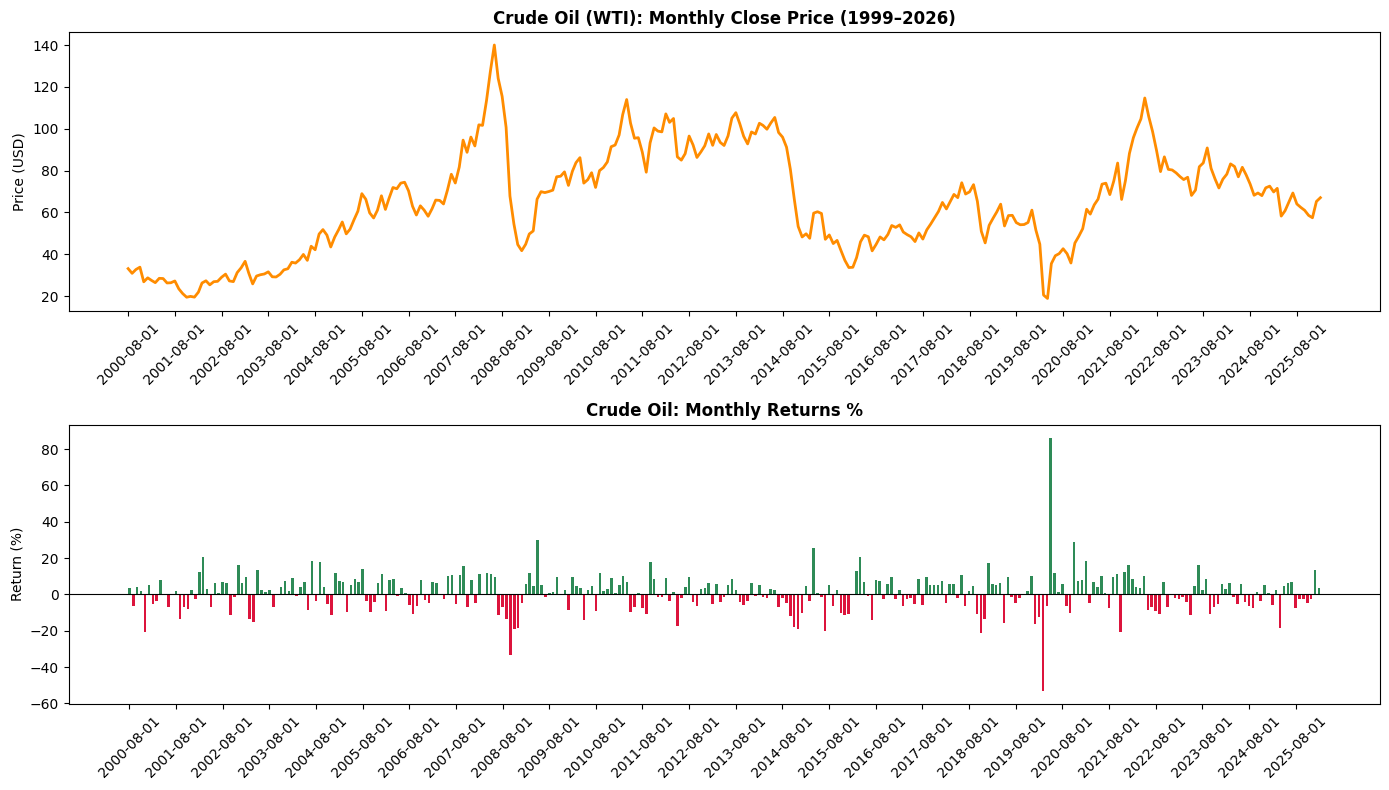

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Price trend
axes[0].plot(crude_df['Month'], crude_df['Month_Close'], color='darkorange', linewidth=2)
axes[0].set_title('Crude Oil (WTI): Monthly Close Price (1999–2026)', fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].set_xticks(crude_df['Month'][::12])
axes[0].tick_params(axis='x', rotation=45)

# Monthly returns
crude_df['Monthly_Return_%'] = (crude_df['Month_Close'] - crude_df['Month_Open']) / crude_df['Month_Open'] * 100
colors = crude_df['Monthly_Return_%'].apply(lambda x: 'seagreen' if x > 0 else 'crimson')
axes[1].bar(crude_df['Month'], crude_df['Monthly_Return_%'], color=colors, width=20)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Crude Oil: Monthly Returns %', fontweight='bold')
axes[1].set_ylabel('Return (%)')
axes[1].set_xticks(crude_df['Month'][::12])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

* from this we can understand that the price of crude oil can drastically change, unlike nifty which has cyclical nature, crude oil is different

* Here we will only consider the baseline feature of crude oil.

In [19]:
# Feature engineering
crude_df['Monthly_Return_%']  = (crude_df['Month_Close'] - crude_df['Month_Open']) / crude_df['Month_Open'] * 100
crude_df['HL_Range_%']        = (crude_df['Month_High']  - crude_df['Month_Low'])   / crude_df['Month_Open'] * 100
crude_df['Body_Ratio']        = abs(crude_df['Month_Close'] - crude_df['Month_Open']) / (crude_df['Month_High'] - crude_df['Month_Low'])
crude_df['Upper_Shadow_%']    = (crude_df['Month_High'] - crude_df[['Month_Open','Month_Close']].max(axis=1)) / crude_df['Month_Open'] * 100
crude_df['Lower_Shadow_%']    = (crude_df[['Month_Open','Month_Close']].min(axis=1) - crude_df['Month_Low'])  / crude_df['Month_Open'] * 100
crude_df['Recovery_Rate_%']   = (crude_df['Month_Close'] - crude_df['Month_Low']) / (crude_df['Month_High'] - crude_df['Month_Low']) * 100
crude_df['Rolling_CAGR_%']    = crude_df['Month_Close'].pct_change(12) * 100
crude_df['Bull_Return_%']     = crude_df['Monthly_Return_%'].clip(lower=0)
crude_df['Bear_Return_%']     = crude_df['Monthly_Return_%'].clip(upper=0)
crude_df['Prev_Bull_Return_%'] = crude_df['Bull_Return_%'].shift(1)
crude_df['Prev_Bear_Return_%'] = crude_df['Bear_Return_%'].shift(1)



In [20]:
# Target
crude_df['Next_Month_Return_%']   = crude_df['Monthly_Return_%'].shift(-1)
crude_df['Next_Month_Direction']  = (crude_df['Next_Month_Return_%'] > 0).astype(int)



In [21]:
crude_df.dropna(inplace=True)
print(crude_df.shape)
print(crude_df.isnull().sum())

(294, 19)
Month                   0
Month_Open              0
Month_Close             0
Month_High              0
Month_Low               0
Avg_Volume              0
Monthly_Return_%        0
HL_Range_%              0
Body_Ratio              0
Upper_Shadow_%          0
Lower_Shadow_%          0
Recovery_Rate_%         0
Rolling_CAGR_%          0
Bull_Return_%           0
Bear_Return_%           0
Prev_Bull_Return_%      0
Prev_Bear_Return_%      0
Next_Month_Return_%     0
Next_Month_Direction    0
dtype: int64


In [22]:
feature_cols_crude = [
    'Monthly_Return_%', 'HL_Range_%', 'Body_Ratio',
    'Upper_Shadow_%', 'Lower_Shadow_%', 'Recovery_Rate_%',
    'Avg_Volume', 'Prev_Bull_Return_%', 'Prev_Bear_Return_%',
    'Rolling_CAGR_%'
]

x = crude_df[feature_cols_crude]
y_reg = crude_df['Next_Month_Return_%']
y_clf = crude_df['Next_Month_Direction']

split = int(len(crude_df) * 0.8)

x_train, x_test = x.iloc[:split], x.iloc[split:]
y_reg_train, y_reg_test = y_reg.iloc[:split], y_reg.iloc[split:]
y_clf_train, y_clf_test = y_clf.iloc[:split], y_clf.iloc[split:]

print(f"Train: {x_train.shape}, Test: {x_test.shape}")

Train: (235, 10), Test: (59, 10)


In [30]:
models_reg = {
    'Ridge':        Ridge(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost':      XGBRegressor(n_estimators=100, random_state=42)
}

models_clf = {
    'LogisticReg':  LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':      XGBClassifier(n_estimators=100, random_state=42),
    'SVM':          SVC(),
    'KNN':          KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'NaiveBayes':   GaussianNB()
}

print("=== REGRESSION ===")
for name, model in models_reg.items():
    model.fit(x_train, y_reg_train)
    pred = model.predict(x_test)
    print(f"{name:15} MAE: {mean_absolute_error(y_reg_test, pred):.3f}  RMSE: {root_mean_squared_error(y_reg_test, pred):.3f}")

print("\n=== CLASSIFICATION ===")
for name, model in models_clf.items():
    model.fit(x_train, y_clf_train)
    pred = model.predict(x_test)
    print(f"{name:15} Accuracy: {accuracy_score(y_clf_test, pred):.3f}  F1: {f1_score(y_clf_test, pred):.3f}")

=== REGRESSION ===
Ridge           MAE: 7.063  RMSE: 8.493
RandomForest    MAE: 7.884  RMSE: 9.367
XGBoost         MAE: 7.728  RMSE: 9.187

=== CLASSIFICATION ===
LogisticReg     Accuracy: 0.441  F1: 0.522


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForest    Accuracy: 0.390  F1: 0.500
XGBoost         Accuracy: 0.458  F1: 0.556
SVM             Accuracy: 0.508  F1: 0.674
KNN             Accuracy: 0.576  F1: 0.638
DecisionTree    Accuracy: 0.407  F1: 0.493
NaiveBayes      Accuracy: 0.508  F1: 0.065


In [34]:


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled  = scaler.transform(x_test)

models_reg = {
    'Ridge':        Ridge(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost':      XGBRegressor(n_estimators=100, random_state=42)
}

models_clf = {
    'LogisticReg':  LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':      XGBClassifier(n_estimators=100, random_state=42),
    'SVM':          SVC(),
    'KNN':          KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'NaiveBayes':   GaussianNB()
}

# Scale-sensitive models
scale_models = {'LogisticReg', 'SVM', 'KNN'}

print("=== REGRESSION ===")
for name, model in models_reg.items():
    model.fit(x_train, y_reg_train)
    pred = model.predict(x_test)
    print(f"{name:15} MAE: {mean_absolute_error(y_reg_test, pred):.3f}  RMSE: {root_mean_squared_error(y_reg_test, pred):.3f}")

print("\n=== CLASSIFICATION ===")
for name, model in models_clf.items():
    Xtr = X_train_scaled if name in scale_models else x_train
    Xte = X_test_scaled  if name in scale_models else x_test
    model.fit(Xtr, y_clf_train)
    pred = model.predict(Xte)
    print(f"{name:15} Accuracy: {accuracy_score(y_clf_test, pred):.3f}  F1: {f1_score(y_clf_test, pred):.3f}")

=== REGRESSION ===
Ridge           MAE: 7.063  RMSE: 8.493
RandomForest    MAE: 7.884  RMSE: 9.367
XGBoost         MAE: 7.728  RMSE: 9.187

=== CLASSIFICATION ===
LogisticReg     Accuracy: 0.475  F1: 0.563
RandomForest    Accuracy: 0.390  F1: 0.500
XGBoost         Accuracy: 0.458  F1: 0.556
SVM             Accuracy: 0.424  F1: 0.575
KNN             Accuracy: 0.458  F1: 0.515
DecisionTree    Accuracy: 0.407  F1: 0.493
NaiveBayes      Accuracy: 0.508  F1: 0.065


* These results confirm the earlier finding — crude oil OHLC features alone cannot predict direction reliably. Most models are below 0.5 accuracy (worse than random guessing).

*Adding macro features*

In [35]:
gold   = yf.download('GC=F',  start='1999-01-01', end='2026-03-01')['Close'].resample('MS').last().squeeze()
usdinr = yf.download('INR=X', start='1999-01-01', end='2026-03-01')['Close'].resample('MS').last().squeeze()

macro_crude = pd.DataFrame({'Gold': gold, 'USDINR': usdinr}).reset_index()
macro_crude.columns = ['Month', 'Gold', 'USDINR']
macro_crude['Gold_Change_%']         = macro_crude['Gold'].pct_change()   * 100
macro_crude['USDINR_Change_%']       = macro_crude['USDINR'].pct_change() * 100
macro_crude['Prev_Gold_Change_%']    = macro_crude['Gold_Change_%'].shift(1)
macro_crude['Prev_USDINR_Change_%']  = macro_crude['USDINR_Change_%'].shift(1)

print(macro_crude.isnull().sum())

/tmp/ipykernel_176/307590762.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold   = yf.download('GC=F',  start='1999-01-01', end='2026-03-01')['Close'].resample('MS').last().squeeze()
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_176/307590762.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usdinr = yf.download('INR=X', start='1999-01-01', end='2026-03-01')['Close'].resample('MS').last().squeeze()
[*********************100%***********************]  1 of 1 completed

Month                    0
Gold                     0
USDINR                  40
Gold_Change_%            1
USDINR_Change_%         41
Prev_Gold_Change_%       2
Prev_USDINR_Change_%    42
dtype: int64
